# ToxiciTOOL — Reprodução dos Modelos Campeões

**Notebook de reprodutibilidade autocontido.**

Partindo apenas dos CSVs brutos em `data/data_raw/`, este notebook reconstrói todos os artefatos intermediários necessários (fingerprints, splits) e treina o modelo campeão — garantindo que qualquer pesquisador com o repositório clonado chegue ao mesmo resultado.

**Fluxo:**
1. Trava global de estocasticidade
2. Verifica quais artefatos já existem — só reconstrói o que falta
3. Treina o modelo campeão com os hiperparâmetros do treinamento
4. Gera métricas e gráficos de publicação

## 1. Travamento absoluto da estocasticidade


In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_XLA_FLAGS"]         = "--tf_xla_enable_xla_devices=false"
os.environ["TF_ENABLE_XLA"]        = "0"

print(f"Seeds travadas: SEED={SEED}")
print(f"TensorFlow {tf.__version__} | GPUs disponíveis: {len(tf.config.list_physical_devices('GPU'))}")

Seeds travadas: SEED=42
TensorFlow 2.21.0 | GPUs disponíveis: 1


## 2. Imports e resolução do path

In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# Resolve a raiz do projeto independente de onde o notebook está
_NB   = Path().resolve()
_REPO = _NB
while not (_REPO / "src").exists() and _REPO != _REPO.parent:
    _REPO = _REPO.parent

sys.path.insert(0, str(_REPO / "src"))

from config import PATHS, VIAS, Y_COLS, SPLIT, DESCRITORES
from modeling.modelagem_MTL import modelo_multitask, CamadaIncerteza

print(f"Raiz do projeto : {_REPO}")
print(f"VIAS modeladas  : {VIAS}")
print(f"Descritores     : ativo={DESCRITORES['ativo']} | n={len(DESCRITORES['lista'])}")

Raiz do projeto : /home/m40ista/Projetos/Toxicitool
VIAS modeladas  : ['mouse_vi', 'mouse_vo', 'mouse_ip', 'rat_vi', 'rat_vo', 'rat_ip']
Descritores     : ativo=True | n=10


## 3. Selecione o experimento a reproduzir

Edite apenas as duas variáveis abaixo. O notebook detecta automaticamente
quais artefatos intermediários precisam ser gerados.

In [3]:
# ── CONFIGURAÇÃO DO EXPERIMENTO ─────────────────────────────────────────────
PKL_CAMPEAO  = "MTL_df_final_quantitativo_4096bits_raio2__desc.pkl"
METODO_SPLIT = "butina"    # "scaffold" | "butina" | "random"

# ── Caminhos derivados ───────────────────────────────────────────────────────
_CHAVE_SPLIT = {"scaffold": "splits_scaffold", "butina": "splits_butina", "random": "splits_random"}
pkl_path = PATHS["preprocessed"] / PKL_CAMPEAO
stem     = Path(PKL_CAMPEAO).stem
npz_path = PATHS[_CHAVE_SPLIT[METODO_SPLIT]] / f"{stem}__indices.npz"

print(f"PKL alvo : {pkl_path}")
print(f"NPZ alvo : {npz_path}")
print(f"PKL existe: {pkl_path.exists()} | NPZ existe: {npz_path.exists()}")

PKL alvo : /home/m40ista/Projetos/Toxicitool/data/preprocessed/MTL_df_final_quantitativo_4096bits_raio2__desc.pkl
NPZ alvo : /home/m40ista/Projetos/Toxicitool/data/splits/butina/MTL_df_final_quantitativo_4096bits_raio2__desc__indices.npz
PKL existe: True | NPZ existe: True


## 4. Etapa 1 — Pré-processamento (condicional)

Roda apenas se `MTL_df_base_fundida.pkl` ainda não existir.
Requer os CSVs em `data/data_raw/`.

In [4]:
base_path = PATHS["preprocessed"] / "MTL_df_base_fundida.pkl"

if base_path.exists():
    print(f"✓ Base fundida já existe: {base_path}")
else:
    print("Etapa 1 — executando pré-processamento...")
    from preprocessing.preprocessamento_MTL import main as preproc_main
    preproc_main()
    print(f"✓ Base fundida gerada: {base_path}")

✓ Base fundida já existe: /home/m40ista/Projetos/Toxicitool/data/preprocessed/MTL_df_base_fundida.pkl


## 5. Etapa 2 — Fingerprints (condicional)

Gera apenas o PKL do experimento escolhido, não o grid completo de 18.
Isso acelera a reprodução para o modelo campeão específico.

In [5]:
if pkl_path.exists():
    print(f"✓ PKL já existe: {pkl_path.name}")
else:
    print(f"Etapa 2 — gerando fingerprints para: {PKL_CAMPEAO}")
    import gc, itertools
    from representation.Representacao import Representacao

    # Extrai hiperparâmetros do nome do arquivo
    # Formato: MTL_df_final_{tipo}_{bits}bits_raio{r}__desc.pkl
    partes    = stem.replace("MTL_df_final_", "").replace("__desc", "").split("_")
    use_count = partes[0] == "quantitativo"
    fp_size   = int(partes[1].replace("bits", ""))
    radius    = int(partes[2].replace("raio", ""))

    print(f"  → tipo={'contagem' if use_count else 'binário'} | bits={fp_size} | raio={radius}")

    df_base = pd.read_pickle(base_path)
    prep    = Representacao(dataframe=df_base)
    df_base = prep.mol_to_frame(col_smiles="smiles")
    df_base.dropna(subset=["ROMol"], inplace=True)
    df_base.reset_index(drop=True, inplace=True)

    rep    = Representacao(dataframe=df_base.copy())
    df_fps = rep.fp_Morgan(col_frames="ROMol", radius=radius, fpSize=fp_size, use_count=use_count)
    df_fps = rep.bitVect_to_array("Fingerprint")

    if DESCRITORES["ativo"]:
        df_fps = rep.calcular_descritores(col_smiles="smiles", lista_descritores=DESCRITORES["lista"])
        df_fps = rep.concatenar_descritores()

    df_fps = df_fps.drop(columns=["ROMol", "Fingerprint"], errors="ignore")
    df_fps.to_pickle(pkl_path)
    print(f"✓ PKL gerado: {pkl_path.name} | shape={df_fps.shape}")
    gc.collect()

✓ PKL já existe: MTL_df_final_quantitativo_4096bits_raio2__desc.pkl


## 6. Etapa 2.5 — Split (condicional)

Computa os índices de split para o experimento escolhido se ainda não existirem.

In [6]:
if npz_path.exists():
    print(f"✓ NPZ já existe: {npz_path.name}")
else:
    print(f"Etapa 2.5 — computando split '{METODO_SPLIT}'...")
    from modeling.Splitter import Splitter

    df_split   = pd.read_pickle(pkl_path)
    splitter   = Splitter(dataframe=df_split, smiles_col="smiles")
    n          = len(df_split)
    BUTINA_MAX = 8_000

    if METODO_SPLIT == "scaffold":
        train_idx, test_idx = splitter.scaffold_split(
            test_size=SPLIT["test_size"], random_state=SPLIT["random_state"]
        )
    elif METODO_SPLIT == "butina":
        if n <= BUTINA_MAX:
            print(f"  n={n:,} ≤ {BUTINA_MAX:,} → Butina clássico")
            train_idx, test_idx = splitter.butina_split(
                test_size=SPLIT["test_size"],
                tanimoto_cutoff=SPLIT["tanimoto_cutoff"],
                random_state=SPLIT["random_state"],
            )
        else:
            print(f"  n={n:,} > {BUTINA_MAX:,} → Butina-batch (leader-follower)")
            train_idx, test_idx = splitter.butina_batch_split(
                test_size=SPLIT["test_size"],
                tanimoto_cutoff=SPLIT["tanimoto_cutoff"],
                random_state=SPLIT["random_state"],
            )
    else:
        train_idx, test_idx = splitter.random_split(
            test_size=SPLIT["test_size"], random_state=SPLIT["random_state"]
        )

    np.savez(npz_path, train_idx=train_idx, test_idx=test_idx)
    print(f"✓ NPZ salvo: {npz_path.name} | treino={len(train_idx)} | teste={len(test_idx)}")

✓ NPZ já existe: MTL_df_final_quantitativo_4096bits_raio2__desc__indices.npz


## 7. Carregamento dos artefatos

In [7]:
df         = pd.read_pickle(pkl_path)
split_data = np.load(npz_path)
train_idx  = split_data["train_idx"]
test_idx   = split_data["test_idx"]

print(f"DataFrame : {df.shape[0]} moléculas × {df.shape[1]} colunas")
print(f"Treino    : {len(train_idx):>6} ({100*len(train_idx)/len(df):.1f}%)")
print(f"Teste     : {len(test_idx):>6}  ({100*len(test_idx)/len(df):.1f}%)")

DataFrame : 70361 moléculas × 8 colunas
Treino    :  56288 (80.0%)
Teste     :  14073  (20.0%)


## 8. Preparação dos tensores X e y

In [8]:
X       = np.stack(df["Features"].tolist()).astype(np.float32)
X_train = X[train_idx]
X_test  = X[test_idx]

y_train = {via: df[col].values[train_idx] for via, col in Y_COLS.items() if col in df.columns}
y_test  = {via: df[col].values[test_idx]  for via, col in Y_COLS.items() if col in df.columns}

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_test  : {X_test.shape}")
print()
print(f"{'Via':12s} {'n_treino':>10} {'n_teste':>10}")
print("─" * 35)
for via in VIAS:
    if via in y_train:
        nt = int((~np.isnan(y_train[via])).sum())
        nv = int((~np.isnan(y_test[via])).sum())
        print(f"{via:12s} {nt:>10} {nv:>10}")

X_train : (56288, 4106)  dtype=float32
X_test  : (14073, 4106)

Via            n_treino    n_teste
───────────────────────────────────
mouse_vi          13153       3227
mouse_vo          18056       4619
mouse_ip          28199       6967
rat_vi             1857        429
rat_vo             7831       1992
rat_ip             3905        866


## 9. Instanciação da arquitetura MTL

In [9]:
model = modelo_multitask(fpSize=X_train.shape[1])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_fingerprint   │ (None, 4106)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,102,272 │ input_fingerprin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,072 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,768 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incerteza_layer     │ (None, 128)       │          6 │ dropout_2[0][0]   │
│ (CamadaIncerteza)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mouse_vi (Dense)    │ (None, 1)         │        129 │ incerteza_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mouse_vo (Dense)    │ (None, 1)         │        129 │ incerteza_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mouse_ip (Dense)    │ (None, 1)         │        129 │ incerteza_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rat_vi (Dense)      │ (None, 1)         │        129 │ incerteza_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rat_vo (Dense)      │ (None, 1)         │        129 │ incerteza_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rat_ip (Dense)      │ (None, 1)         │        129 │ incerteza_layer[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,270,476 (8.66 MB)

 Trainable params: 2,268,684 (8.65 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 10. Treinamento

In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
        ),
    ],
    verbose=1,
)
print(f"\nTreinamento concluído em {len(history.history['loss'])} épocas.")

Epoch 1/200


E0000 00:00:1776719361.489916  384512 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_20}}


198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.3554 - mouse_ip_loss: 0.3798 - mouse_vi_loss: 0.0862 - mouse_vo_loss: 0.1537 - rat_ip_loss: 0.0198 - rat_vi_loss: -0.0160 - rat_vo_loss: 0.0919 - val_loss: 0.7859 - val_mouse_ip_loss: 0.1723 - val_mouse_vi_loss: -0.0098 - val_mouse_vo_loss: 0.1151 - val_rat_ip_loss: -0.0407 - val_rat_vi_loss: -0.0820 - val_rat_vo_loss: 0.0219 - learning_rate: 5.0000e-04
Epoch 2/200
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2090 - mouse_ip_loss: 0.0428 - mouse_vi_loss: -0.0644 - mouse_vo_loss: -0.0227 - rat_ip_loss: -0.1137 - rat_vi_loss: -0.1313 - rat_vo_loss: -0.0762 - val_loss: -0.3485 - val_mouse_ip_loss: -0.0976 - val_mouse_vi_loss: -0.1538 - val_mouse_vo_loss: -0.1136 - val_rat_ip_loss: -0.1736 - val_rat_vi_loss: -0.1918 - val_rat_vo_loss: -0.1566 - learning_rate: 5.0000e-04
Epoch 3/200
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: -0.5672 - mouse_ip_loss: -0.0980 - mouse_vi_loss: -0.1848 - mouse_vo_loss: -0.1462 - rat_ip_loss: -0.2191

## 11. Curva de aprendizado

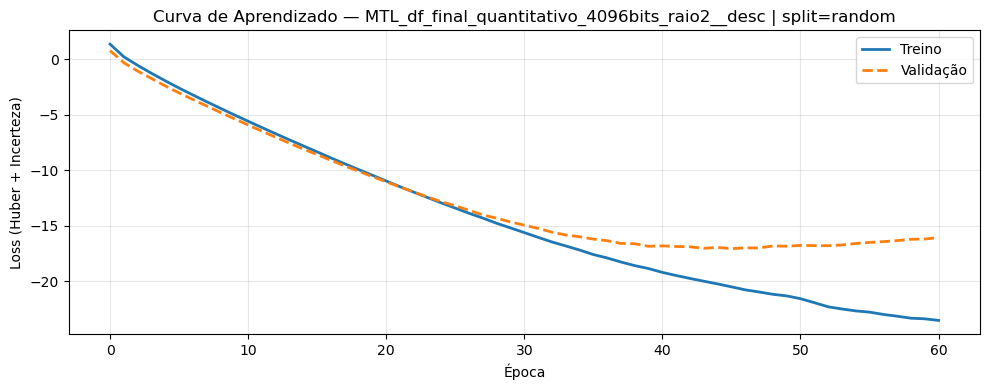

Salvo: /home/m40ista/Projetos/Toxicitool/results/plots/multitask/analise/learning_curve_MTL_df_final_quantitativo_4096bits_raio2__desc__random.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"],     label="Treino",    linewidth=2)
ax.plot(history.history["val_loss"], label="Validação", linewidth=2, linestyle="--")
ax.set_xlabel("Época"); ax.set_ylabel("Loss (Huber + Incerteza)")
ax.set_title(f"Curva de Aprendizado — {stem} | split={METODO_SPLIT}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
out = _REPO / f"results/plots/multitask/analise/learning_curve_{stem}__{METODO_SPLIT}.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150); plt.show()
print(f"Salvo: {out}")

## 12. Métricas por via

In [12]:
predicoes = model.predict(X_test, verbose=0)
metricas  = {}

print(f"{'Via':12s} {'n_teste':>8} {'R²':>8} {'MAE':>8}")
print("─" * 42)

for i, (via, col) in enumerate(Y_COLS.items()):
    if via not in y_test:
        continue
    y_t, y_p = y_test[via], predicoes[i].flatten()
    mask      = ~np.isnan(y_t)
    y_t_l, y_p_l = y_t[mask], y_p[mask]
    if len(y_t_l) < 2:
        print(f"{via:12s} {'—':>8} {'—':>8} {'—':>8}")
        continue
    r2  = r2_score(y_t_l, y_p_l)
    mae = mean_absolute_error(y_t_l, y_p_l)
    metricas[via] = {"r2": r2, "mae": mae, "n": int(mask.sum())}
    print(f"{via:12s} {mask.sum():>8} {r2:>8.4f} {mae:>8.4f}")

r2_medio  = np.mean([m["r2"]  for m in metricas.values()])
mae_medio = np.mean([m["mae"] for m in metricas.values()])
print("─" * 42)
print(f"{'MÉDIA':12s} {'':>8} {r2_medio:>8.4f} {mae_medio:>8.4f}")

E0000 00:00:1776718783.353890  376400 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Via           n_teste       R²      MAE
──────────────────────────────────────────
mouse_vi         3346   0.5739   0.3092
mouse_vo         4484   0.4833   0.2882
mouse_ip         7001   0.5554   0.2925
rat_vi            499   0.6495   0.3660
rat_vo           1985   0.5760   0.4162
rat_ip            980   0.5554   0.3662
──────────────────────────────────────────
MÉDIA                   0.5656   0.3397


## 13. Dispersão predito vs. real por via

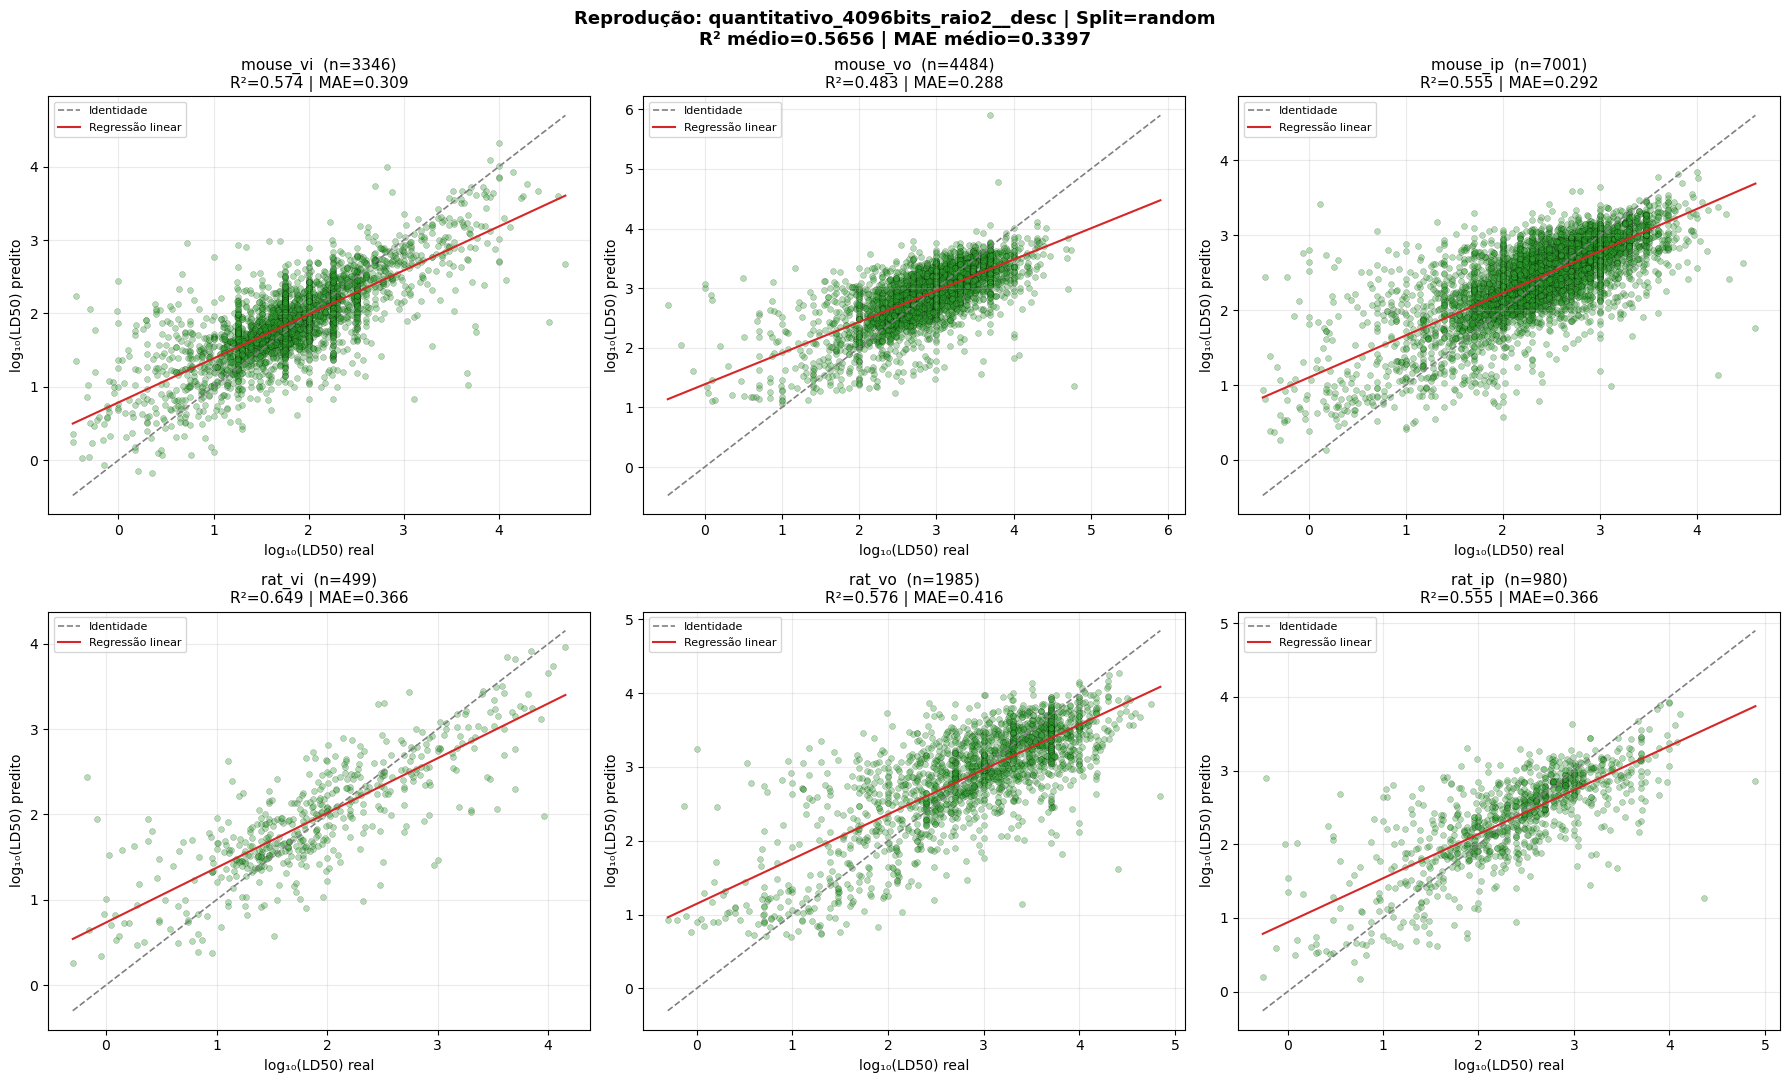

Salvo: /home/m40ista/Projetos/Toxicitool/results/plots/multitask/analise/reproducao_MTL_df_final_quantitativo_4096bits_raio2__desc__random.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (via, col) in enumerate(Y_COLS.items()):
    ax = axes[i]
    if via not in metricas:
        ax.set_title(f"{via}\nSem dados"); ax.axis("off"); continue

    y_t, y_p = y_test[via], predicoes[i].flatten()
    mask = ~np.isnan(y_t)
    y_t_l, y_p_l = y_t[mask], y_p[mask]
    r2, mae = metricas[via]["r2"], metricas[via]["mae"]

    ax.scatter(y_t_l, y_p_l, alpha=0.35, color="#2ca02c", edgecolors="k", linewidths=0.3, s=18)
    mn, mx = min(y_t_l.min(), y_p_l.min()), max(y_t_l.max(), y_p_l.max())
    ax.plot([mn, mx], [mn, mx], "gray", linestyle="--", linewidth=1.2, label="Identidade")
    m, b = np.polyfit(y_t_l, y_p_l, 1)
    xs = np.linspace(mn, mx, 100)
    ax.plot(xs, m*xs+b, color="#d62728", linewidth=1.5, label="Regressão linear")
    ax.set_xlabel("log₁₀(LD50) real", fontsize=10)
    ax.set_ylabel("log₁₀(LD50) predito", fontsize=10)
    ax.set_title(f"{via}  (n={metricas[via]['n']})\nR²={r2:.3f} | MAE={mae:.3f}", fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.suptitle(
    f"Reprodução: {stem.replace('MTL_df_final_','')} | Split={METODO_SPLIT}\n"
    f"R² médio={r2_medio:.4f} | MAE médio={mae_medio:.4f}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
out = _REPO / f"results/plots/multitask/analise/reproducao_{stem}__{METODO_SPLIT}.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=200); plt.show()
print(f"Salvo: {out}")

## 14. Incerteza homocedástica aprendida (σ por via)

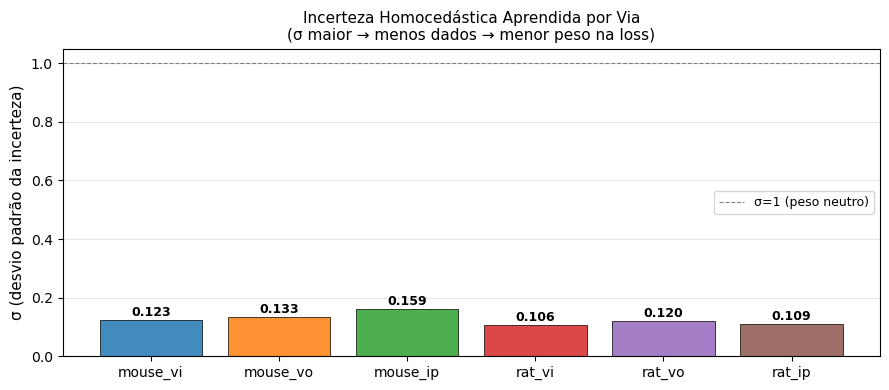


σ por via (ordenado por incerteza decrescente):
  mouse_ip    : σ=0.1593  ███
  mouse_vo    : σ=0.1326  ██
  mouse_vi    : σ=0.1231  ██
  rat_vo      : σ=0.1198  ██
  rat_ip      : σ=0.1094  ██
  rat_vi      : σ=0.1060  ██


In [15]:
try:
    log_vars = model.get_layer("incerteza_layer").get_weights()[0]
    sigmas   = np.exp(log_vars / 2)

    fig, ax = plt.subplots(figsize=(9, 4))
    cores   = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]
    bars    = ax.bar(VIAS, sigmas, color=cores, alpha=0.85, edgecolor="k", linewidth=0.6)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="σ=1 (peso neutro)")
    for bar, s in zip(bars, sigmas):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{s:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylabel("σ (desvio padrão da incerteza)", fontsize=11)
    ax.set_title("Incerteza Homocedástica Aprendida por Via\n(σ maior → menos dados → menor peso na loss)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    out = _REPO / f"results/plots/multitask/analise/incerteza_{stem}__{METODO_SPLIT}.png"
    plt.savefig(out, dpi=150)
    plt.show()

    print("\nσ por via (ordenado por incerteza decrescente):")
    for v, s in sorted(zip(VIAS, sigmas), key=lambda x: -x[1]):
        barra = "█" * int(s * 20)
        print(f"  {v:12s}: σ={s:.4f}  {barra}")
except Exception as e:
    print(f"Camada de incerteza não encontrada: {e}")

## 15. Resumo de reprodutibilidade

In [16]:
import datetime

print("=" * 62)
print("  RESUMO DE REPRODUTIBILIDADE — ToxiciTOOL")
print("=" * 62)
print(f"  Data/hora        : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Experimento      : {PKL_CAMPEAO}")
print(f"  Método de split  : {METODO_SPLIT}")
print(f"  TensorFlow       : {tf.__version__}")
print(f"  SEED global      : {SEED}")
print(f"  X_train shape    : {X_train.shape}")
print(f"  X_test shape     : {X_test.shape}")
print(f"  Épocas efetivas  : {len(history.history['loss'])}")
print(f"  Descritores      : {DESCRITORES['lista']}")
print()
print(f"  {'Via':12s} {'n':>6} {'R²':>8} {'MAE':>8}")
print(f"  {'─'*38}")
for v, m in sorted(metricas.items(), key=lambda x: -x[1]['r2']):
    print(f"  {v:12s} {m['n']:>6} {m['r2']:>8.4f} {m['mae']:>8.4f}")
print(f"  {'─'*38}")
print(f"  {'MÉDIA':12s} {'':>6} {r2_medio:>8.4f} {mae_medio:>8.4f}")
print("=" * 62)

  RESUMO DE REPRODUTIBILIDADE — ToxiciTOOL
  Data/hora        : 2026-04-20 18:05:04
  Experimento      : MTL_df_final_quantitativo_4096bits_raio2__desc.pkl
  Método de split  : random
  TensorFlow       : 2.21.0
  SEED global      : 42
  X_train shape    : (56288, 4106)
  X_test shape     : (14073, 4106)
  Épocas efetivas  : 61
  Descritores      : ['MolLogP', 'MolWt', 'TPSA', 'LabuteASA', 'NumRotatableBonds', 'NumHDonors', 'NumHAcceptors', 'FractionCSP3', 'RingCount', 'NumAromaticRings']

  Via               n       R²      MAE
  ──────────────────────────────────────
  rat_vi          499   0.6495   0.3660
  rat_vo         1985   0.5760   0.4162
  mouse_vi       3346   0.5739   0.3092
  mouse_ip       7001   0.5554   0.2925
  rat_ip          980   0.5554   0.3662
  mouse_vo       4484   0.4833   0.2882
  ──────────────────────────────────────
  MÉDIA                 0.5656   0.3397
